In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],  # fallbacks
    "pdf.fonttype": 42,   # embed TrueType fonts in PDF
    "ps.fonttype": 42,
})

def find_root_by_folder_name(folder_name: str, start: Path | None = None) -> Path:
    """
    Find the nearest ancestor directory whose name matches `folder_name`.

    Works when code is run from different subdirectories inside the project.
    """
    if start is None:
        # Use __file__ in scripts; fall back to cwd in notebooks/interpreters
        try:
            start = Path(__file__).resolve()
        except NameError:
            start = Path.cwd().resolve()
    else:
        start = Path(start).resolve()

    # If start is a file, begin from its parent
    if start.is_file():
        start = start.parent

    for path in [start, *start.parents]:
        if path.name == folder_name:
            return path

    raise FileNotFoundError(
        f"Could not find a parent directory named {folder_name!r} from {start}"
    )


ROOT_DIR = find_root_by_folder_name("filler_gap_detector_childes")
STATS_DIR = ROOT_DIR / "childes_statistics"

# Setting up variables for computing statistics and plotting

In [3]:
# Load data
dir_path = Path(f"{STATS_DIR}/childes_statistics_LABELED")
csv_files = sorted(dir_path.glob("*.csv"))
df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
total_len = len(df)
print(len(csv_files), "files ->", df.shape) # in total 3M rows

# Split by speaker role
df = df[df['target_child_age'].notna()] # remove rows with missing target child age
df = df[(df['target_child_age']<=80)] # only keep children up to 7 years old
print("After removing rows with missing target child age:", len(df), "rows remains. Ratio of rows kept:", len(df) / total_len * 100, "%")
df_child = df[df['speaker_role'].isin(['Target_Child', 'Child'])]
df_adult = df[~df['speaker_role'].isin(['Target_Child', 'Child'])]

# Prepare global variables for plotting
TYPE_GROUPING = {'MatrixQ': ['SMQ', 'OMQ', 'AMQ', 'PMQ', 'PlainMQ', 'CC_SMQ', 'CC_OMQ', 'CC_AMQ'],
             'EmbQ': ['SEQ', 'OEQ', 'AEQ', 'PEQ'],
             'RC': ['SRC', 'ORC', 'ARC', 'PRC', 'SRC_reduced', 'ORC_reduced']}

SUB_GROUPING = {'SMQ': ['SMQ', 'CC_SMQ'],
                'OMQ': ['OMQ', 'CC_OMQ'],
                'NoGAP_MQ': ['AMQ', 'CC_AMQ', 'PMQ', 'PlainMQ'],
                
                'SEQ': ['SEQ'],
                'OEQ': ['OEQ'],
                'NoGAP_EQ': ['AEQ', 'PEQ'],
                
                'SRC': ['SRC', 'SRC_reduced'],
                'ORC': ['ORC', 'ORC_reduced'],
                'NoGAP_RC': ['ARC', 'PRC']}

# Type-level (aggregation_type="type"): no role dimension, so use a neutral mid shade
# but keep it aligned with the family hues you’ve been using conceptually.
SITE_COLOR_HEX = {
    "SUBJ":  "#4093D6",  # blue
    "OBJ":   "#EA8E2C",  # orange
    "NOGAP": "#B47FBB",  # purple
}

PANEL_ORDER = ["Matrix", "EmbQ", "RC"]

PANEL_LABELS = {
    "Matrix": ["SMQ", "OMQ", "NoGAP_MQ"],
    "EmbQ":   ["SEQ", "OEQ", "NoGAP_EQ"],
    "RC":     ["SRC", "ORC", "NoGAP_RC"],
}

def label_to_panel(label: str) -> str | None:
    for panel, labs in PANEL_LABELS.items():
        if label in labs:
            return panel
    return None

def label_to_color(label: str, default: str = "#6B7280") -> str:
    panel = label_to_panel(label)
    if panel is None:
        return default
    return SITE_COLOR_HEX.get(panel, default)


def label_to_site(label: str) -> str:
    # assumes your sub labels are exactly these forms
    if label.startswith("NoGAP_"):
        return "NOGAP"
    # subject-extraction labels
    if label in {"SMQ", "SEQ", "SRC", "CC_SMQ", "SRC_reduced"}:
        return "SUBJ"
    # object-extraction labels
    if label in {"OMQ", "OEQ", "ORC", "CC_OMQ", "ORC_reduced"}:
        return "OBJ"
    return "NOGAP"  # fallback; or return "UNK"

18 files -> (3074103, 10)
After removing rows with missing target child age: 2841084 rows remains. Ratio of rows kept: 92.41993518109184 %


### Plotting Helpers

In [10]:
def _build_reverse_map(grouping: dict[str, list[str]]) -> dict[str, str]:
    rev = {}
    for group_label, fine_list in grouping.items():
        for fine in fine_list:
            if fine in rev and rev[fine] != group_label:
                raise ValueError(f"Label '{fine}' appears in multiple groups: {rev[fine]} and {group_label}")
            rev[fine] = group_label
    return rev


def parse_labels_cell(x):
    """
    Parse df['parser_labels'] cell into a clean list[str].

    Handles:
      - already-a-list
      - NaN/None
      - string representations like "['PMQ']" or "[]"
      - single strings like "PMQ"
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return [str(t) for t in x if str(t).strip()]

    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "nan":
            return []
        # Most common bug: CSV stores lists as strings. Try literal_eval.
        if (s.startswith("[") and s.endswith("]")) or (s.startswith("(") and s.endswith(")")):
            try:
                y = ast.literal_eval(s)
                if isinstance(y, list):
                    return [str(t) for t in y if str(t).strip()]
            except Exception:
                # fall through: treat the whole string as one label
                pass
        # Otherwise treat as a single label token
        return [s]

    # unknown type -> coerce
    return [str(x)]


def wilson_ci(k: np.ndarray, n: np.ndarray, z: float = 1.96):
    k = k.astype(float)
    n = n.astype(float)
    low = np.zeros_like(k, dtype=float)
    high = np.zeros_like(k, dtype=float)
    m = n > 0
    km, nm = k[m], n[m]
    phat = km / nm
    denom = 1.0 + (z**2) / nm
    center = (phat + (z**2) / (2*nm)) / denom
    half = (z * np.sqrt((phat*(1-phat) + (z**2)/(4*nm)) / nm)) / denom
    low[m] = np.clip(center - half, 0.0, 1.0)
    high[m] = np.clip(center + half, 0.0, 1.0)
    return low, high

def compute_label_counts(
    df: pd.DataFrame,
    *,
    aggregation_type: str | None = "sub",   # None | "sub" | "type"
    exclude_labels: set[str] | None = None,
    drop_unmapped: bool = False,
) -> pd.DataFrame:
    """
    Count utterances per label (post-aggregation).
    Multi-label utterances contribute +1 to each label they contain (deduped per utterance).
    Empty label lists [] are ignored (no bar).
    """
    exclude_labels = exclude_labels or set()

    d = df.copy()
    d["parser_labels"] = d["parser_labels"].apply(parse_labels_cell)

    # build reverse map for aggregation
    if aggregation_type is None:
        rev = None
    elif aggregation_type == "type":
        rev = _build_reverse_map(TYPE_GROUPING)
    elif aggregation_type == "sub":
        rev = _build_reverse_map(SUB_GROUPING)
    else:
        raise ValueError("aggregation_type must be one of: None, 'type', 'sub'")

    def map_labels(labels):
        if rev is None:
            mapped = labels
        else:
            mapped = []
            for lab in labels:
                if lab in rev:
                    mapped.append(rev[lab])
                else:
                    if not drop_unmapped:
                        mapped.append(lab)
        mapped = sorted(set(mapped))  # de-dup within utterance
        mapped = [m for m in mapped if m not in exclude_labels and m not in ("", None)]
        return mapped

    d["labels_mapped"] = d["parser_labels"].apply(map_labels)

    # explode to (utterance,label) rows; drop empties (NaN from empty list)
    expl = d[["id", "labels_mapped"]].explode("labels_mapped").rename(columns={"labels_mapped": "label"})
    expl = expl[expl["label"].notna()].copy()

    counts = (expl.groupby("label", as_index=False)
                  .agg(count=("id", "count"))
                  .sort_values("count", ascending=False))
    return counts

# Reproducing Figure 4 in Section 5.1

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

def _plot_a1_overlay_on_ax_compact_legend(
    ax,
    a1_adult: pd.DataFrame,
    a1_child: pd.DataFrame,
    *,
    labels: list[str],
    exclude_labels: set[str],
    title: str,
    ylim: tuple[float, float] | None,
    color_map: dict[str, str],
    unknown_color: str = "#6B7280",
    show_ci: bool = True,
    ci_alpha_adult: float = 0.18,
    ci_alpha_child: float = 0.10,
    adult_linestyle: str = "-",
    child_linestyle: str = "--",
    linewidth: float = 2.0,
    ylabel: str = "Rate per 1,000 utterances",
    title_fontsize: int = 16,
    xlabel_fontsize: int = 18,
    ylabel_fontsize: int = 18,
    tick_fontsize: int = 16,
):
    # Filter labels for this panel
    panel_labels = [lab for lab in labels if lab not in (exclude_labels or set())]

    for lab in panel_labels:
        site = label_to_site(lab)
        color = SITE_COLOR_HEX.get(site, unknown_color)


        # adult (THIS is what will show up in the panel legend)
        suba = a1_adult[a1_adult["label"] == lab].sort_values("age_bin")
        if not suba.empty:
            x = suba["age_bin"].to_numpy()
            y = suba["rate_per_1k"].to_numpy()
            ax.plot(x, y, linestyle=adult_linestyle, linewidth=linewidth, color=color, label='_nolegend_')

            if show_ci and ("ci_low_per_1k" in suba.columns) and ("ci_high_per_1k" in suba.columns):
                lo = suba["ci_low_per_1k"].to_numpy()
                hi = suba["ci_high_per_1k"].to_numpy()
                ax.fill_between(x, lo, hi, alpha=ci_alpha_adult, color=color)

        # child (no legend entry)
        subc = a1_child[a1_child["label"] == lab].sort_values("age_bin")
        if not subc.empty:
            xc = subc["age_bin"].to_numpy()
            yc = subc["rate_per_1k"].to_numpy()
            ax.plot(xc, yc, linestyle=child_linestyle, linewidth=linewidth, color=color, label="_nolegend_")

            if show_ci and ("ci_low_per_1k" in subc.columns) and ("ci_high_per_1k" in subc.columns):
                loc = subc["ci_low_per_1k"].to_numpy()
                hic = subc["ci_high_per_1k"].to_numpy()
                ax.fill_between(xc, loc, hic, alpha=ci_alpha_child, color=color)

    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel("Age (months, bin size = 6)", fontsize=xlabel_fontsize)
    ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

    if ylim is not None:
        ax.set_ylim(ylim)


def plot_a1_three_panels_horizontal_with_split_legends(
    a1_adult: pd.DataFrame,
    a1_child: pd.DataFrame,
    *,
    labels9: list[str],
    color_map: dict[str, str],
    # panel-specific settings (yours)
    mq_exclude={"SEQ", "OEQ", "NoGAP_EQ", "SRC", "ORC", "NoGAP_RC"},
    mq_ylim=(-1, 150),
    eq_exclude={"SRC", "ORC", "NoGAP_RC", "SMQ", "OMQ", "NoGAP_MQ"},
    eq_ylim=(-1, 15),
    rc_exclude={"SEQ", "OEQ", "NoGAP_EQ", "SMQ", "OMQ", "NoGAP_MQ"},
    rc_ylim=(-1, 15),
    # legend placement inside each subplot
    panel_legend_loc="upper left",
    panel_legend_bbox=(0.02, 0.98),  # inside axes
    panel_legend_fontsize=9,
    panel_legend_ncol=1,
    fig_width: float = 22,
    fig_height: float = 5,
    title_fontsize: int = 24,
    xlabel_fontsize: int = 22,
    ylabel_fontsize: int = 22,
    tick_fontsize: int = 20,
    global_legend_fontsize: int = 18, # NEW
):
    fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharex=False, sharey=False)

    _plot_a1_overlay_on_ax_compact_legend(
        axes[0], a1_adult, a1_child,
        labels=labels9, exclude_labels=mq_exclude,
        title="Matrix Questions", ylim=mq_ylim,
        color_map=color_map,
        title_fontsize=title_fontsize,
        xlabel_fontsize=xlabel_fontsize,
        ylabel_fontsize=ylabel_fontsize,
        tick_fontsize=tick_fontsize
    )
    _plot_a1_overlay_on_ax_compact_legend(
        axes[1], a1_adult, a1_child,
        labels=labels9, exclude_labels=eq_exclude,
        title="Embedded Questions", ylim=eq_ylim,
        color_map=color_map,
        title_fontsize=title_fontsize,
        xlabel_fontsize=xlabel_fontsize,
        ylabel_fontsize=ylabel_fontsize,
        tick_fontsize=tick_fontsize
    )
    _plot_a1_overlay_on_ax_compact_legend(
        axes[2], a1_adult, a1_child,
        labels=labels9, exclude_labels=rc_exclude,
        title="Relative Clauses", ylim=rc_ylim,
        color_map=color_map,
        title_fontsize=title_fontsize,
        xlabel_fontsize=xlabel_fontsize,
        ylabel_fontsize=ylabel_fontsize,
        tick_fontsize=tick_fontsize
    )

    # --- per-panel label legends (inside each axes) ---
    site_handles = [
        Patch(facecolor=SITE_COLOR_HEX["SUBJ"], edgecolor="none", label="Subject gap"),
        Patch(facecolor=SITE_COLOR_HEX["OBJ"],  edgecolor="none", label="Object gap"),
        Patch(facecolor=SITE_COLOR_HEX["NOGAP"],edgecolor="none", label="Other"),
    ]

    for ax in axes:
        leg = ax.legend(
            handles=site_handles,
            loc=panel_legend_loc,
            bbox_to_anchor=panel_legend_bbox,
            bbox_transform=ax.transAxes,
            fontsize=panel_legend_fontsize,
            ncol=panel_legend_ncol,
            frameon=True,
            framealpha=0.80,
            facecolor="white",
            edgecolor="0.8",
        )
        leg.set_zorder(10)

    # --- global Adult/Child style legend on the right ---
    style_handles = [
        Line2D([0], [0], color="black", linewidth=2.5, linestyle="-", label="Adult"),
        Line2D([0], [0], color="black", linewidth=2.5, linestyle="--", label="Child"),
    ]
    fig.legend(
        handles=style_handles,
        loc="center left",          # anchor legend's left edge
        bbox_to_anchor=(0.915, 0.5),# smaller x => closer to rightmost subplot
        frameon=False,
        fontsize=global_legend_fontsize,
    )

    fig.tight_layout(rect=[0, 0, 0.92, 1])  # give a bit less reserved space
    plt.show()
    fig.savefig(f"{STATS_DIR}/figures/overall_by_month_triplots.pdf", dpi=300, bbox_inches="tight")


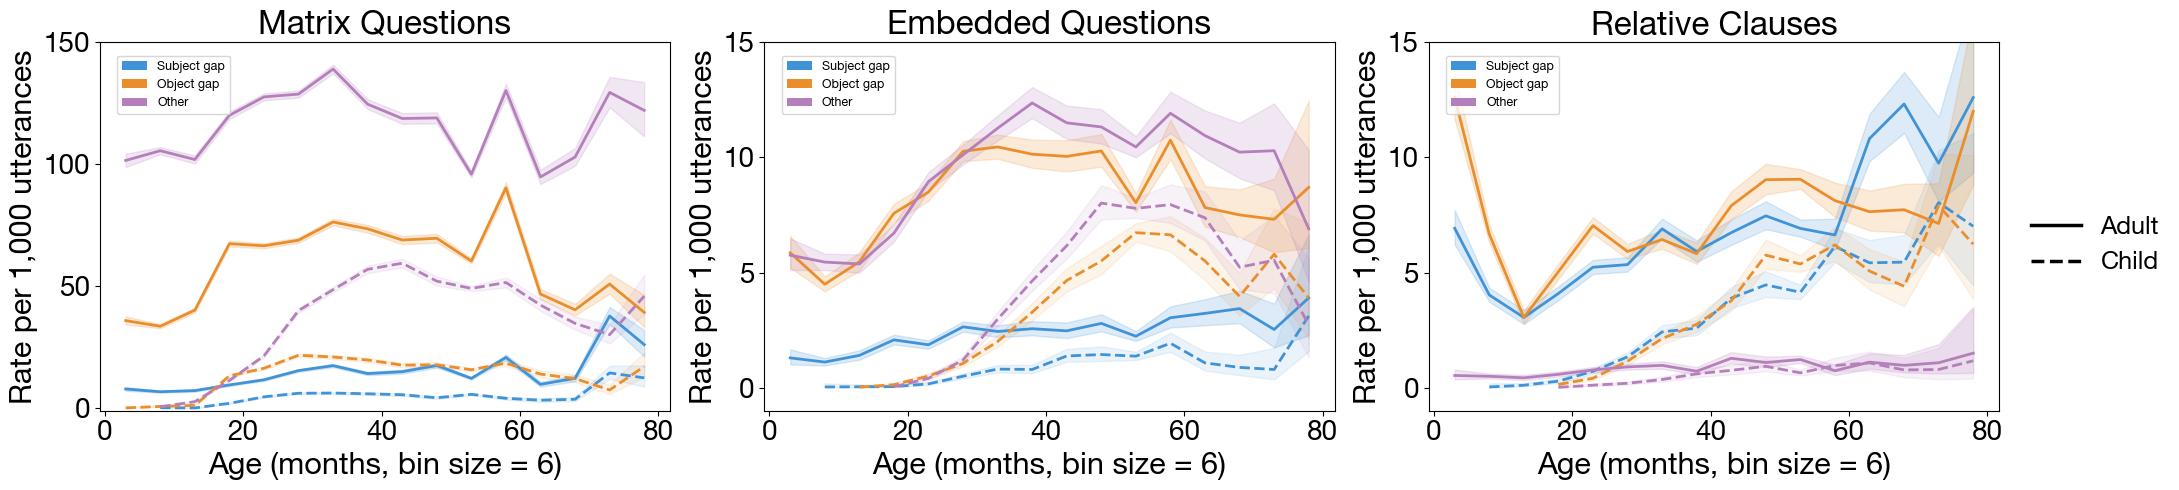

In [ ]:
labels9 = ["SMQ","OMQ","NoGAP_MQ","SEQ","OEQ","NoGAP_EQ","SRC","ORC","NoGAP_RC"]

a1_adult = prepare_a1(df_adult, age_bin_months=5, aggregation_type="sub", add_ci=True)
a1_child = prepare_a1(df_child, age_bin_months=5, aggregation_type="sub", add_ci=True)

plot_a1_three_panels_horizontal_with_split_legends(
    a1_adult, a1_child,
    labels9=labels9,
    color_map=SITE_COLOR_HEX,   # or your role-primary mapping
)

# Reproducing Figure 5 in Section 5.2

In [ ]:
def _add_age_bin(df: pd.DataFrame, age_bin_months: int) -> pd.DataFrame: 
    d = df.copy() 
    d["age_bin"] = (np.floor(d["target_child_age"] / age_bin_months) * age_bin_months).astype(int) 
    return d

def compute_monthly_fgd_stacked_counts(
    df_group: pd.DataFrame, 
    *,
    age_bin_months: int = 1, 
    exclude_labels: set[str] | None = None): 
    """ Returns per-age-bin counts: age_bin, total, fgd_present, fgd_absent, fgd_rate where fgd_present means >=1 label after excluding exclude_labels. """ 
    exclude_labels = exclude_labels or set() 
    d = _add_age_bin(df_group, age_bin_months=age_bin_months) 
    
    # parse label cell robustly (uses your helper) 
    d["parser_labels"] = d["parser_labels"].apply(parse_labels_cell) 
    
    def has_fgd(labels): 
        if not labels: 
            return False 
        labs = [x for x in labels if x not in exclude_labels] 
        return len(labs) > 0 
    
    d["has_fgd"] = d["parser_labels"].apply(has_fgd) 
    agg = (d.groupby("age_bin", as_index=False) 
           .agg(total=("id", "count"), 
                fgd_present=("has_fgd", "sum"))) 
    agg["fgd_present"] = agg["fgd_present"].astype(int) 
    agg["fgd_absent"] = (agg["total"] - agg["fgd_present"]).astype(int) 
    agg["fgd_rate"] = agg["fgd_present"] / agg["total"].replace(0, np.nan) 
    return agg.sort_values("age_bin")

In [ ]:
def compute_monthly_fgd_rate_per_1k(
    df_group: pd.DataFrame,
    *,
    age_bin_months: int = 1,
    exclude_labels: set[str] | None = None,
) -> pd.DataFrame:
    """
    Returns per-age-bin stats:
      age_bin, total, fgd_present, fgd_rate, fgd_per_1k
    where fgd_present means >=1 label after excluding exclude_labels.
    """
    exclude_labels = exclude_labels or set()
    d = _add_age_bin(df_group, age_bin_months=age_bin_months)

    d["parser_labels"] = d["parser_labels"].apply(parse_labels_cell)

    def has_fgd(labels):
        if not labels:
            return False
        labs = [x for x in labels if x not in exclude_labels]
        return len(labs) > 0

    d["has_fgd"] = d["parser_labels"].apply(has_fgd)

    agg = (d.groupby("age_bin", as_index=False)
             .agg(total=("id", "count"),
                  fgd_present=("has_fgd", "sum")))
    agg["fgd_present"] = agg["fgd_present"].astype(int)
    agg["fgd_rate"] = agg["fgd_present"] / agg["total"].replace(0, np.nan)
    agg["fgd_per_1k"] = 1000.0 * agg["fgd_rate"].fillna(0.0)

    return agg.sort_values("age_bin")


def plot_monthly_fgd_rate_per_1k_side_by_side(
    df_adult: pd.DataFrame,
    df_child: pd.DataFrame,
    *,
    age_bin_months: int = 1,
    exclude_labels: set[str] | None = None,
    # styling
    title: str | None = None,
    fig_width: float = 14,
    fig_height: float = 4.2,
    adult_label: str = "Adult",
    child_label: str = "Child",
    child_hatch: str = "///",
    child_hatch_edgecolor: str = "#111827",
    bar_edge_lw: float = 0.8,
    bar_width: float = 0.42,
    pair_offset: float | None = None,     # if None => bar_width/2
    cat_spacing: float = 1.2,             # <1 squeezes months closer
    # fonts
    xlabel_fontsize: int = 22,
    ylabel_fontsize: int = 22,
    tick_fontsize: int = 18,
    title_fontsize: int = 24,
    legend_fontsize: int = 18,
    annotation_fontsize: int = 15,
    # ratio annotation
    ratio_digits: int = 2,
    ratio_inf_thresh: float = 100.0,
    ratio_eps: float = 1e-12,
    # y headroom
    y_headroom_mult: float = 1.10,
    # save
    savepath: str | None = None,
    dpi: int = 300,
):
    """
    One-panel plot: for each month (age_bin),
      - two bars: Adult (solid) and Child (hatched)
      - bar height = (#FGD / #Total) * 1000  (FGD per 1,000 utterances)
      - annotation above each month: (Adult fgd_rate) / (Child fgd_rate),
        printed as ∞ if ratio > ratio_inf_thresh.

    Returns (A_tbl, C_tbl) the monthly tables for adult/child.
    """
    exclude_labels = exclude_labels or set()
    color_adult = "#2e75a9"
    color_child = "#ef9240"


    A = compute_monthly_fgd_rate_per_1k(df_adult, age_bin_months=age_bin_months, exclude_labels=exclude_labels)
    C = compute_monthly_fgd_rate_per_1k(df_child, age_bin_months=age_bin_months, exclude_labels=exclude_labels)

    # Align bins
    bins = sorted(set(A["age_bin"]).union(set(C["age_bin"])))
    A = A.set_index("age_bin").reindex(bins).fillna(0).reset_index()
    C = C.set_index("age_bin").reindex(bins).fillna(0).reset_index()

    x = np.arange(len(bins)) * cat_spacing
    width = float(bar_width)
    offset = (width / 2) if (pair_offset is None) else float(pair_offset)

    A_y = A["fgd_per_1k"].to_numpy(dtype=float)
    C_y = C["fgd_per_1k"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Adult bars (solid, default matplotlib blue)
    barsA = ax.bar(x - offset, A_y, width=width, label=adult_label,
               color=color_adult, edgecolor="none")

    # Child bars (hatched, default matplotlib orange)
    barsC = ax.bar(x + offset, C_y, width=width, label=child_label,
               color=color_child, edgecolor="none")


    # --- ratio annotations: (Adult fgd_rate) / (Child fgd_rate) ---
    A_rate = A["fgd_rate"].to_numpy(dtype=float)
    C_rate = C["fgd_rate"].to_numpy(dtype=float)
    ratio = A_rate / np.maximum(C_rate, ratio_eps)

    # y position for text: slightly above the taller of the two bars
    y_max = np.maximum(A_y, C_y)

    for xi, r, ytop in zip(x, ratio, y_max):
        if not np.isfinite(r):
            continue
        if r > ratio_inf_thresh:
            txt = r"$\infty$"
        else:
            txt = f"{r:.{ratio_digits}f}"
        ax.text(
            xi,
            ytop * 1.03 + 0.02,  # small pad in linear coords
            txt,
            ha="center",
            va="bottom",
            fontsize=annotation_fontsize,
            clip_on=False,
        )

    # Axis labels / ticks
    ax.set_xlabel("Target child age (months)", fontsize=xlabel_fontsize)
    ax.set_ylabel("Number of FGD \nper 1,000 utterances", fontsize=ylabel_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

    # Use actual month values as tick labels (sparser if too dense)
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in bins], rotation=0, ha="center")

    # Reduce whitespace on ends
    ax.set_xlim(x.min() - width * 2, x.max() + width * 2)

    # Add a bit of headroom
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, max(ymax, np.max(y_max) * y_headroom_mult + 0.2))

    # Legends: Adult/Child style (vertical, outside right)
    style_handles = [
        Patch(facecolor=color_adult, edgecolor="black", linewidth=1.0, label=adult_label),
        Patch(facecolor=color_child, edgecolor="black", linewidth=1.0, label=child_label),
    ]
    ax.legend(
        handles=style_handles,
        fontsize=legend_fontsize,
        loc="upper left",
        bbox_to_anchor=(0.88, 0.98),
        borderaxespad=0,
        frameon=False,
    )

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    plt.show()
    return A, C


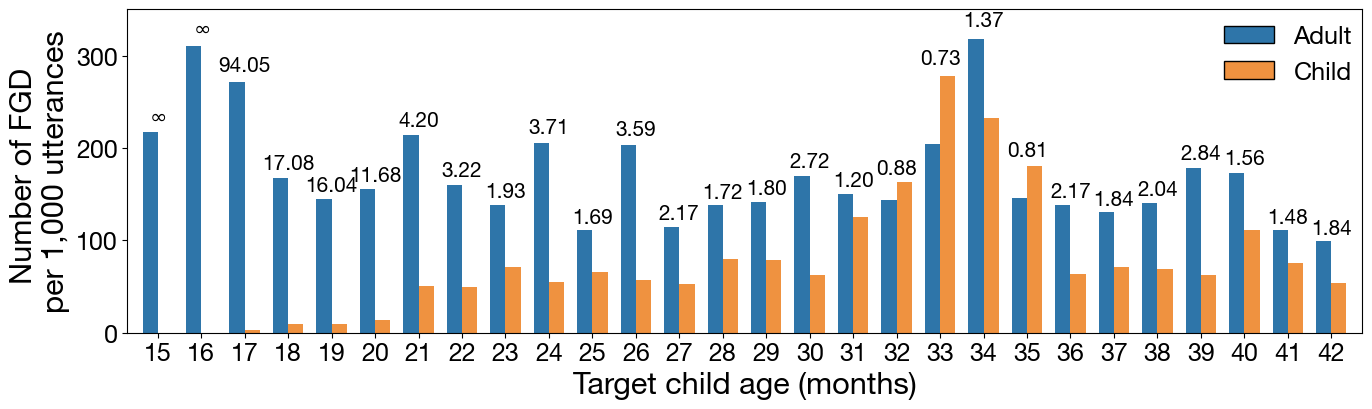

In [ ]:
exclude = set()
A_tbl, C_tbl = plot_monthly_fgd_rate_per_1k_side_by_side(
    df_individual_adult,
    df_individual_child,
    age_bin_months=1,
    exclude_labels=exclude,
    title=None,
    savepath=f"{STATS_DIR}/figures/laura_monthly_fgd_per_1k.pdf",
)


# Reproducing Figure 7 in Section 5.2

In [4]:
trans = pd.read_csv(f'{STATS_DIR}/Processed_Transcripts.csv')
trans[trans['study_type']=='long']
print(trans[trans['study_type']=='long']['target_child_name'].value_counts().head(10))

# check which corpora have data for Laura in the long study type
# Julia, Sean, Trevor are all from the ComptonPater corpus, age range roughly 10-39 months
trans[(trans['study_type']=='long') & (trans['target_child_name']=='Laura')]['corpus_name'].value_counts()

target_child_name
Laura     911
Julia     421
Sean      347
Trevor    244
Abe       210
E         200
Sarah     142
Naomi      93
Naima      88
Lily       80
Name: count, dtype: int64


corpus_name
Braunwald     900
McCune          8
NewEngland      3
Name: count, dtype: int64

### Load data for an Individual Child (can be reused for other individuals)

In [5]:
def load_individual_data(target_child_name: str, corpus_name: str, age_min: int = None, age_max: int = None) -> pd.DataFrame:

    target_transcriptions = trans[(trans['study_type']=='long') & (trans['target_child_name']==target_child_name) & (trans['corpus_name'] == corpus_name)]['transcript_id'].tolist()
    
    df_individual = df[df['transcript_id'].isin(target_transcriptions)]
    print(f"Age range: {df_individual['target_child_age'].min()} to {df_individual['target_child_age'].max()}")

    if age_min is not None and age_max is not None:
        df_individual = df_individual[df_individual['target_child_age'].between(age_min, age_max)]

    df_individual_child = df_individual[df_individual['speaker_role'].isin(['Target_Child', 'Child'])]
    df_individual_adult = df_individual[~df_individual['speaker_role'].isin(['Target_Child', 'Child'])]
    
    return df_individual, df_individual_child, df_individual_adult

In [6]:
# df_individual, df_individual_child, df_individual_adult = load_individual_data("Trevor", "ComptonPater", age_min=None, age_max=None)
df_individual, df_individual_child, df_individual_adult = load_individual_data("Laura", "Braunwald", age_min=15, age_max=43)
print(f"Adult speeches: {len(df_individual_adult)}, Child speeches: {len(df_individual_child)}")

Age range: 15.0331628986221 to 77.1001457935481
Adult speeches: 40659, Child speeches: 35081


### Plotting

In [8]:
def plot_label_counts_side_by_side_three_panels(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    *,
    name1: str = "Adult",
    name2: str = "Child",
    aggregation_type: str | None = "sub",
    exclude_labels: set[str] | None = None,
    drop_unmapped: bool = False,
    log_base: int = 10,
    rotate_xticks: int = 0,
    title: str | None = None,

    # style knobs (preserve your previous settings)
    unknown_color: str = "#6B7280",
    child_hatch: str = "///",
    child_hatch_edgecolor: str = "#111827",
    bar_edge_lw: float = 0.8,

    xlabel_fontsize: int = 24,
    ylabel_fontsize: int = 23,
    tick_fontsize: int = 22,
    title_fontsize: int = 24,
    panel_title_fontsize: int = 24,
    legend_fontsize: int = 18,
    annotation_fontsize: int = 18,
    annotation_rotation: int = 0,
    annotation_pad_mult: float = 1.03,

    fig_width: float = 15,
    fig_height: float = 4.5,
    savepath: str | None = "figures/laura_total_by_type.pdf",
    dpi: int = 300,
):
    exclude_labels = exclude_labels or set()

    # counts per label
    c1 = compute_label_counts(df1, aggregation_type=aggregation_type,
                              exclude_labels=exclude_labels, drop_unmapped=drop_unmapped).rename(columns={"count": name1})
    c2 = compute_label_counts(df2, aggregation_type=aggregation_type,
                              exclude_labels=exclude_labels, drop_unmapped=drop_unmapped).rename(columns={"count": name2})

    merged = pd.merge(c1, c2, on="label", how="outer").fillna(0)
    merged[name1] = merged[name1].astype(int)
    merged[name2] = merged[name2].astype(int)
    merged["sum"] = merged[name1] + merged[name2]

    # Ensure all 9 labels appear (even if count=0) so each panel always has 3 bars
    all9 = [lab for panel in PANEL_ORDER for lab in PANEL_LABELS[panel]]
    merged = pd.concat([merged, pd.DataFrame({"label": all9})], ignore_index=True)
    merged = merged.drop_duplicates(subset=["label"], keep="first").fillna(0)
    merged[name1] = merged[name1].astype(int)
    merged[name2] = merged[name2].astype(int)
    merged["sum"] = merged[name1] + merged[name2]

    fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True)

    def _annotate(ax, bar_container, values):
        for rect, val in zip(bar_container, values):
            if val <= 0:
                continue
            x_center = rect.get_x() + rect.get_width() / 2
            y_top = rect.get_height()
            ax.text(
                x_center,
                y_top * annotation_pad_mult,
                f"{int(val)}",
                ha="center",
                va="bottom",
                fontsize=annotation_fontsize,
                rotation=annotation_rotation,
                clip_on=False,
            )

    for ax, panel in zip(axes, PANEL_ORDER):
        labs = PANEL_LABELS[panel]
        sub = merged.set_index("label").reindex(labs).reset_index().fillna(0)

        x = np.arange(len(labs)) * 0.9
        width = 0.35

        colors = [SITE_COLOR_HEX.get(label_to_site(lab), unknown_color) for lab in labs]


        # Adult (solid)
        bars1 = ax.bar(
            x - width/2,
            sub[name1].to_numpy(),
            width=width,
            color=colors,
            edgecolor="none",
        )

        # Child (hatched), same fill color
        bars2 = ax.bar(
            x + width/2,
            sub[name2].to_numpy(),
            width=width,
            color=colors,
            hatch=child_hatch,
            edgecolor=child_hatch_edgecolor,
            linewidth=bar_edge_lw,
        )

        ax.set_yscale("log", base=log_base)
        ax.set_title({"Matrix": "Matrix Questions", "EmbQ": "Embedded Questions", "RC": "Relative Clauses"}[panel],
                     fontsize=panel_title_fontsize)

        ax.set_xticks(x)
        display_labs = [lab.replace("NoGAP_", "Other_") for lab in labs]  # nicer label display
        ax.set_xticklabels(display_labs, rotation=rotate_xticks, ha="center", fontsize=tick_fontsize)
        ax.tick_params(axis="y", labelsize=tick_fontsize)

        _annotate(ax, bars1, sub[name1].to_numpy())
        _annotate(ax, bars2, sub[name2].to_numpy())

    # shared labels + optional overall title
    axes[0].set_ylabel(f"Count of utterances (log{log_base})", fontsize=ylabel_fontsize)
    for ax in axes:
        ax.set_xlabel("Extraction site", fontsize=xlabel_fontsize)

    if title is not None:
        fig.suptitle(title, fontsize=title_fontsize, y=1.02)
        

    # --- one compact legend (Adult vs Child style) ---
    style_handles = [
        Patch(facecolor="white", edgecolor="black", linewidth=1.0, label=name1),
        Patch(facecolor="white", edgecolor=child_hatch_edgecolor, hatch=child_hatch, linewidth=1.0, label=name2),
    ]
    axes[-1].legend(handles=style_handles, fontsize=legend_fontsize,
                    loc="upper right", bbox_to_anchor=(0.98, 0.98), borderaxespad=0)

    # add a bit of headroom on log axis (shared)
    ymin, ymax = axes[0].get_ylim()
    axes[0].set_ylim(ymin, ymax * 1.35)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    plt.show()
    return merged


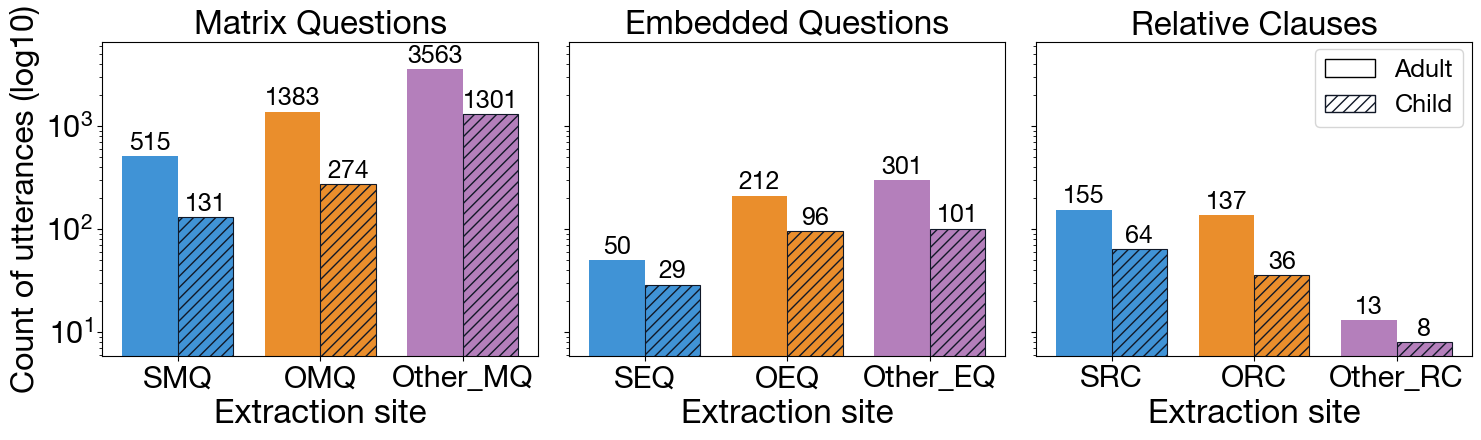

In [11]:
tbl = plot_label_counts_side_by_side_three_panels(
    df_individual_adult, df_individual_child,
    name1="Adult", name2="Child",
    aggregation_type="sub",
    rotate_xticks=0,
    title=None,  # optional
    child_hatch="///",
    savepath=f"{STATS_DIR}/figures/laura_total_by_type.pdf",
)


# Reproducing Figure 6 in Section 5.3

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyparsing import line
from matplotlib.ticker import MultipleLocator

# ---- same as before (edit if your label set differs) ----
SO_ROLE_MAP = {
    "MatrixQ": {"subj": ["SMQ", "CC_SMQ"], "obj": ["OMQ", "CC_OMQ"]},
    "EmbQ":    {"subj": ["SEQ"],          "obj": ["OEQ"]},
    "RC":      {"subj": ["SRC", "SRC_reduced"], "obj": ["ORC", "ORC_reduced"]},
}

def _pivot_rates(a1_long: pd.DataFrame, value_col: str = "rate_per_1k") -> pd.DataFrame:
    return (
        a1_long.pivot(index="age_bin", columns="label", values=value_col)
              .fillna(0.0)
              .sort_index()
    )


def compute_c1_sor(
    df_adult: pd.DataFrame,
    df_child: pd.DataFrame,
    *,
    age_bin_months: int = 1,
    eps: float = 0.05,                 # in per-1k units
    aggregation_type: str = "sub",     # must be "sub"
    exclude_labels: set[str] | None = None,
    add_ci: bool = True,
    min_count: int | None = None,      # NEW: drop bins with total(subj+obj)<min_count (set sor=NaN)
):
    """
    Returns a dataframe with columns:
      speaker_group, dep_type, age_bin, sor, total_cnt

    If add_ci=True, also includes:
      sor_low, sor_high  (conservative Wilson-propagated bounds)

    If min_count is not None, rows with total_cnt < min_count will have sor (and CI) set to NaN
    so plotted lines break in low-data bins.
    """
    exclude_labels = exclude_labels or set()
    if aggregation_type != "sub":
        raise ValueError("C1 needs aggregation_type='sub' so SMQ/OMQ/SEQ/OEQ/SRC/ORC exist.")

    # A1 for adult/child
    a1A = prepare_a1(df_adult, age_bin_months=age_bin_months,
                     aggregation_type="sub", add_ci=add_ci)
    a1C = prepare_a1(df_child, age_bin_months=age_bin_months,
                     aggregation_type="sub", add_ci=add_ci)

    a1A = a1A[~a1A["label"].isin(exclude_labels)].copy()
    a1C = a1C[~a1C["label"].isin(exclude_labels)].copy()

    # Wide rate tables
    A_rate = _pivot_rates(a1A, "rate_per_1k")
    C_rate = _pivot_rates(a1C, "rate_per_1k")

    # Wide count tables (gap-bearing numerator counts per bin)
    A_cnt = _pivot_rates(a1A, "n_label")
    C_cnt = _pivot_rates(a1C, "n_label")

    # Align bins across everything
    age_bins = sorted(set(A_rate.index).union(set(C_rate.index)).union(set(A_cnt.index)).union(set(C_cnt.index)))
    A_rate = A_rate.reindex(age_bins).fillna(0.0)
    C_rate = C_rate.reindex(age_bins).fillna(0.0)
    A_cnt  = A_cnt.reindex(age_bins).fillna(0.0)
    C_cnt  = C_cnt.reindex(age_bins).fillna(0.0)

    # Main SOR table (+ total_cnt, + min_count masking)
    main_rows = []
    for dep_type, roles in SO_ROLE_MAP.items():
        subj_labels = roles["subj"]
        obj_labels  = roles["obj"]

        # Rates (per 1k)
        A_subj = A_rate.reindex(columns=subj_labels, fill_value=0.0).sum(axis=1)
        A_obj  = A_rate.reindex(columns=obj_labels,  fill_value=0.0).sum(axis=1)
        C_subj = C_rate.reindex(columns=subj_labels, fill_value=0.0).sum(axis=1)
        C_obj  = C_rate.reindex(columns=obj_labels,  fill_value=0.0).sum(axis=1)

        A_sor = np.log((A_subj + eps) / (A_obj + eps))
        C_sor = np.log((C_subj + eps) / (C_obj + eps))

        # Counts (gap-bearing numerator counts)
        A_subj_cnt = A_cnt.reindex(columns=subj_labels, fill_value=0.0).sum(axis=1)
        A_obj_cnt  = A_cnt.reindex(columns=obj_labels,  fill_value=0.0).sum(axis=1)
        C_subj_cnt = C_cnt.reindex(columns=subj_labels, fill_value=0.0).sum(axis=1)
        C_obj_cnt  = C_cnt.reindex(columns=obj_labels,  fill_value=0.0).sum(axis=1)

        A_tot_cnt = (A_subj_cnt + A_obj_cnt).to_numpy()
        C_tot_cnt = (C_subj_cnt + C_obj_cnt).to_numpy()

        for i, age in enumerate(age_bins):
            a_val = float(A_sor.iloc[i])
            c_val = float(C_sor.iloc[i])
            a_tot = float(A_tot_cnt[i])
            c_tot = float(C_tot_cnt[i])

            if (min_count is not None) and (a_tot < min_count):
                a_val = np.nan
            if (min_count is not None) and (c_tot < min_count):
                c_val = np.nan

            main_rows.append({
                "speaker_group": "Adult", "dep_type": dep_type, "age_bin": age,
                "sor": a_val, "total_cnt": a_tot
            })
            main_rows.append({
                "speaker_group": "Child", "dep_type": dep_type, "age_bin": age,
                "sor": c_val, "total_cnt": c_tot
            })

    main = pd.DataFrame(main_rows)

    if not add_ci:
        return main.sort_values(["dep_type", "speaker_group", "age_bin"])

    # Wide CI tables (rates per 1k)
    A_lo = _pivot_rates(a1A, "ci_low_per_1k").reindex(age_bins).fillna(0.0)
    A_hi = _pivot_rates(a1A, "ci_high_per_1k").reindex(age_bins).fillna(0.0)
    C_lo = _pivot_rates(a1C, "ci_low_per_1k").reindex(age_bins).fillna(0.0)
    C_hi = _pivot_rates(a1C, "ci_high_per_1k").reindex(age_bins).fillna(0.0)

    ci_rows = []
    for dep_type, roles in SO_ROLE_MAP.items():
        subj_labels = roles["subj"]
        obj_labels  = roles["obj"]

        # Adult conservative bounds
        A_subj_lo = A_lo.reindex(columns=subj_labels, fill_value=0.0).sum(axis=1)
        A_subj_hi = A_hi.reindex(columns=subj_labels, fill_value=0.0).sum(axis=1)
        A_obj_lo  = A_lo.reindex(columns=obj_labels,  fill_value=0.0).sum(axis=1)
        A_obj_hi  = A_hi.reindex(columns=obj_labels,  fill_value=0.0).sum(axis=1)
        A_sor_lo  = np.log((A_subj_lo + eps) / (A_obj_hi + eps))
        A_sor_hi  = np.log((A_subj_hi + eps) / (A_obj_lo + eps))

        # Child conservative bounds
        C_subj_lo = C_lo.reindex(columns=subj_labels, fill_value=0.0).sum(axis=1)
        C_subj_hi = C_hi.reindex(columns=subj_labels, fill_value=0.0).sum(axis=1)
        C_obj_lo  = C_lo.reindex(columns=obj_labels,  fill_value=0.0).sum(axis=1)
        C_obj_hi  = C_hi.reindex(columns=obj_labels,  fill_value=0.0).sum(axis=1)
        C_sor_lo  = np.log((C_subj_lo + eps) / (C_obj_hi + eps))
        C_sor_hi  = np.log((C_subj_hi + eps) / (C_obj_lo + eps))

        for i, age in enumerate(age_bins):
            ci_rows.append({
                "speaker_group": "Adult", "dep_type": dep_type, "age_bin": age,
                "sor_low": float(A_sor_lo.iloc[i]), "sor_high": float(A_sor_hi.iloc[i])
            })
            ci_rows.append({
                "speaker_group": "Child", "dep_type": dep_type, "age_bin": age,
                "sor_low": float(C_sor_lo.iloc[i]), "sor_high": float(C_sor_hi.iloc[i])
            })

    ci = pd.DataFrame(ci_rows)
    out = main.merge(ci, on=["speaker_group", "dep_type", "age_bin"], how="left")

    # If min_count masking made sor NaN, also mask CI so ribbons disappear + line gaps are clean
    m = out["sor"].isna()
    if "sor_low" in out.columns:
        out.loc[m, "sor_low"] = np.nan
        out.loc[m, "sor_high"] = np.nan

    return out.sort_values(["dep_type", "speaker_group", "age_bin"])


def plot_c1_sor(
    c1: pd.DataFrame,
    *,
    title: str | None = "C1: Subject–Object extraction ratio (log) over age",
    show_ci: bool = True,
    show_points: bool = True,
    point_scale: float = 0.8,
    min_point_size: float = 10,
    max_point_size: float = 120,
    # ---- font knobs ----
    fig_width: float = 15,
    fig_height: float = 4,
    title_fontsize: int = 20,
    panel_title_fontsize: int = 22,
    xlabel_fontsize: int = 20,
    ylabel_fontsize: int = 20,
    tick_fontsize: int = 18,
    legend_fontsize: int = 16,
):
    """
    Faceted (3 panels) plot: MatrixQ / EmbQ / RC.
    Adult vs Child lines; optional CI ribbons; optional point sizes ∝ total_cnt.
    NaNs in 'sor' create gaps automatically (for min_count filtering).
    """
    dep_keys = ["MatrixQ", "EmbQ", "RC"]
    dep_display = ["Matrix Questions", "Embedded Questions", "Relative Clauses"]

    # global size map for points
    if show_points and ("total_cnt" in c1.columns):
        t = c1["total_cnt"].to_numpy()
        t = t[np.isfinite(t)]
        tmin = float(np.min(t)) if len(t) else 0.0
        tmax = float(np.max(t)) if len(t) else 1.0

        def size_map(x):
            if tmax <= tmin:
                return min_point_size
            s = (x - tmin) / (tmax - tmin)
            return min_point_size + s * (max_point_size - min_point_size)
    else:
        def size_map(x):
            return min_point_size

    fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_height), sharey=True)

    for ax, dep_key, dep_name in zip(axes, dep_keys, dep_display):
        sub = c1[c1["dep_type"] == dep_key]

        for grp in ["Adult", "Child"]:
            g = sub[sub["speaker_group"] == grp].sort_values("age_bin")

            # line (NaNs break)
            (line,) = ax.plot(g["age_bin"], g["sor"], label=grp)
            line_color = line.get_color()

            # CI ribbon
            if show_ci and {"sor_low", "sor_high"}.issubset(g.columns) and g["sor_low"].notna().any():
                ax.fill_between(g["age_bin"], g["sor_low"], g["sor_high"], alpha=0.2, color=line_color)


            # points sized by total_cnt (only where sor is not NaN)
            if show_points and ("total_cnt" in g.columns):
                gg = g[g["sor"].notna()].copy()
                if not gg.empty:
                    sizes = np.array([size_map(v) for v in gg["total_cnt"].to_numpy()]) * point_scale
                    ax.scatter(gg["age_bin"], gg["sor"], s=sizes, alpha=0.7, color=line_color)

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(dep_name, fontsize=panel_title_fontsize)
        
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.xaxis.set_major_locator(MultipleLocator(10))

    axes[0].set_ylabel("log ratio of Subject\nover Object rates", fontsize=ylabel_fontsize) #"log((SUBJ+ε)/(OBJ+ε))  [rates per 1k]"
    axes[1].set_xlabel("Target child age (months, bin size = 3)", fontsize=xlabel_fontsize)

    # legend outside right
    axes[-1].legend(loc="upper left", bbox_to_anchor=(0.65, 0.5), borderaxespad=0, fontsize=legend_fontsize)

    if title is not None:
        fig.suptitle(title, y=1.03, fontsize=title_fontsize)

    plt.tight_layout()
    plt.show()
    
    fig.savefig(f"{STATS_DIR}/figures/sor_plot.pdf", dpi=300, bbox_inches="tight")


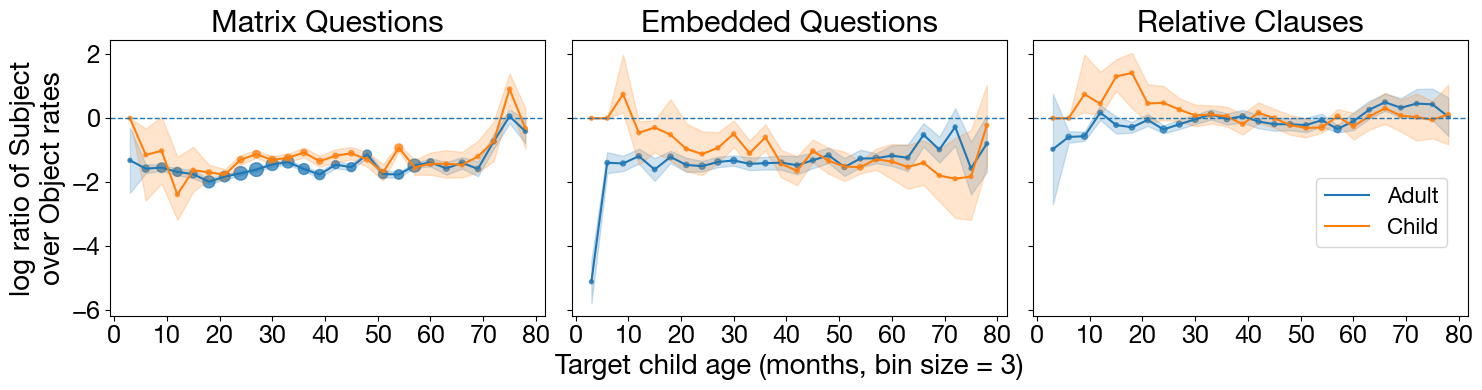

In [ ]:
# df_adult and df_child are already filtered the way you want
c1 = compute_c1_sor(
    df_adult, df_child,
    age_bin_months=3,   # strongly recommended (smoother)
    eps=0.05,
    aggregation_type="sub", # don't change
    add_ci=True
)

plot_c1_sor(c1, title=None, show_ci=True)

# Reproducing Figure 8 in Section 5.3

In [15]:
def prepare_a1(
    df: pd.DataFrame,
    age_bin_months: int = 1,
    aggregation_type: str | None = "sub",
    add_ci: bool = True,
    ci_z: float = 1.96,
    drop_unmapped: bool = False,
    drop_no_gap_categories: bool = False,
    bin_start: int | float | None = None,   # NEW: anchor for bins
) -> pd.DataFrame:
    d = df.copy()
    d["parser_labels"] = d["parser_labels"].apply(parse_labels_cell)

    # ---- NEW: anchor the bins ----
    if bin_start is None:
        bin_start = float(np.nanmin(d["target_child_age"].to_numpy()))
    ages = d["target_child_age"].astype(float)

    d["age_bin"] = (np.floor((ages - bin_start) / age_bin_months) * age_bin_months + bin_start).astype(int)
    # --------------------------------

    denom = d.groupby("age_bin", as_index=False).agg(n_total=("id", "count"))

    if aggregation_type is None:
        rev = None
    elif aggregation_type == "type":
        rev = _build_reverse_map(TYPE_GROUPING)
    elif aggregation_type == "sub":
        rev = _build_reverse_map(SUB_GROUPING)
    else:
        raise ValueError("aggregation_type must be one of: None, 'type', 'sub'")

    def map_labels(labels: list[str]) -> list[str]:
        if rev is None:
            mapped = labels
        else:
            mapped = []
            for lab in labels:
                if lab in rev:
                    mapped.append(rev[lab])
                else:
                    if not drop_unmapped:
                        mapped.append(lab)

        mapped = sorted(set(mapped))
        if drop_no_gap_categories:
            mapped = [m for m in mapped if not str(m).startswith("NoGAP_")]
        return mapped

    d["labels_mapped"] = d["parser_labels"].apply(map_labels)

    expl = d[["id", "age_bin", "labels_mapped"]].explode("labels_mapped").rename(columns={"labels_mapped": "label"})
    expl = expl[expl["label"].notna() & (expl["label"] != "")].copy()

    numer = expl.groupby(["age_bin", "label"], as_index=False).agg(n_label=("id", "count"))

    out = numer.merge(denom, on="age_bin", how="left")
    out["prop"] = out["n_label"] / out["n_total"].replace(0, np.nan)
    out["rate_per_1k"] = 1000.0 * out["prop"].fillna(0.0)

    if add_ci:
        k = out["n_label"].to_numpy()
        n = out["n_total"].to_numpy()
        lo, hi = wilson_ci(k, n, z=ci_z)
        out["ci_low_per_1k"] = 1000.0 * lo
        out["ci_high_per_1k"] = 1000.0 * hi

    return out.sort_values(["age_bin", "label"])

In [ ]:
SO_ROLE_MAP = {
    "MatrixQ": {"subj": ["SMQ", "CC_SMQ"], "obj": ["OMQ", "CC_OMQ"]},
    "EmbQ":    {"subj": ["SEQ"],          "obj": ["OEQ"]},
    "RC":      {"subj": ["SRC", "SRC_reduced"], "obj": ["ORC", "ORC_reduced"]},
}

DEP_ORDER = ["MatrixQ", "EmbQ", "RC"]
DEP_DISPLAY = {"MatrixQ": "Matrix", "EmbQ": "Embedded", "RC": "RC"}

def _pivot_counts(a1_long: pd.DataFrame, value_col: str = "n_label") -> pd.DataFrame:
    """age_bin × label wide table (missing -> 0)."""
    return (a1_long.pivot(index="age_bin", columns="label", values=value_col)
                 .fillna(0.0)
                 .sort_index())

def compute_p_subj_by_bin(
    df: pd.DataFrame,
    *,
    age_bin_months: int = 3,
    exclude_labels: set[str] | None = None,
    min_count: int = 20,
    aggregation_type: str = "sub",
) -> pd.DataFrame:
    """
    Per-bin subject share among gap-bearing tokens:
      p_subj = subj_cnt / (subj_cnt + obj_cnt)
    computed separately for MatrixQ / EmbQ / RC.

    Returns long df:
      dep_type, age_bin, subj_cnt, obj_cnt, total_cnt, p_subj
    Bins with total_cnt < min_count -> p_subj = NaN.
    """
    exclude_labels = exclude_labels or set()
    if aggregation_type != "sub":
        raise ValueError("This expects aggregation_type='sub' so subj/obj sublabels exist.")

    a1 = prepare_a1(df, age_bin_months=age_bin_months, aggregation_type="sub", add_ci=False)
    a1 = a1[~a1["label"].isin(exclude_labels)].copy()

    cnt = _pivot_counts(a1, value_col="n_label")

    age_bins = cnt.index.to_list()
    rows = []
    for dep, roles in SO_ROLE_MAP.items():
        subj = cnt.reindex(columns=roles["subj"], fill_value=0.0).sum(axis=1).to_numpy()
        obj  = cnt.reindex(columns=roles["obj"],  fill_value=0.0).sum(axis=1).to_numpy()
        tot  = subj + obj
        p    = np.where(tot > 0, subj / tot, np.nan)
        p    = np.where(tot >= min_count, p, np.nan)

        for i, age in enumerate(age_bins):
            rows.append({
                "dep_type": dep,
                "age_bin": age,
                "subj_cnt": float(subj[i]),
                "obj_cnt": float(obj[i]),
                "total_cnt": float(tot[i]),
                "p_subj": float(p[i]) if np.isfinite(p[i]) else np.nan,
            })

    return pd.DataFrame(rows).sort_values(["dep_type", "age_bin"])

def summarize_p_subj(
    pbin: pd.DataFrame,
    *,
    dep_order: list[str] = DEP_ORDER,
    n_boot: int = 2000,
    seed: int = 0,
) -> pd.DataFrame:
    """
    Summarize p_subj per dep_type:
      mean, ci_low, ci_high, n_bins
    Bootstrap resamples bins within each dep_type.
    """
    rng = np.random.default_rng(seed)
    rows = []

    for dep in dep_order:
        g = pbin[(pbin["dep_type"] == dep) & (pbin["p_subj"].notna())].copy()
        vals = g["p_subj"].to_numpy(dtype=float)

        if len(vals) == 0:
            rows.append({"dep_type": dep, "mean": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n_bins": 0})
            continue

        mean = float(np.mean(vals))

        idx = np.arange(len(vals))
        boots = np.empty(n_boot, dtype=float)
        for b in range(n_boot):
            samp = vals[rng.choice(idx, size=len(vals), replace=True)]
            boots[b] = np.mean(samp)

        rows.append({
            "dep_type": dep,
            "mean": mean,
            "ci_low": float(np.quantile(boots, 0.025)),
            "ci_high": float(np.quantile(boots, 0.975)),
            "n_bins": int(len(vals)),
        })

    out = pd.DataFrame(rows)
    out["dep_type"] = pd.Categorical(out["dep_type"], categories=dep_order, ordered=True)
    return out.sort_values("dep_type").reset_index(drop=True)


def add_sig_bracket(
    ax, x1, x2, y, text, *,
    dy, lw=1.2, fs=12,
    stem_start_y_left=None,
    stem_start_y_right=None,
):
    """
    Draw a significance bracket from x1 to x2 at baseline y.
    Stems can start at different heights:
      - stem_start_y_left: start of left vertical stem
      - stem_start_y_right: start of right vertical stem
    If not provided, each defaults to y (short stem).
    """
    if not text:
        return

    yL = y if stem_start_y_left is None else stem_start_y_left
    yR = y if stem_start_y_right is None else stem_start_y_right

    # left stem
    ax.plot([x1, x1], [yL, y + dy], lw=lw, color="black", clip_on=False)
    # right stem
    ax.plot([x2, x2], [yR, y + dy], lw=lw, color="black", clip_on=False)
    # cap
    ax.plot([x1, x2], [y + dy, y + dy], lw=lw, color="black", clip_on=False)
    # text
    ax.text((x1 + x2) / 2, y + dy/2, text, ha="center", va="bottom", fontsize=fs)


# ----------------------------------------
# Main plotting: 2 panels, relative layout
# ----------------------------------------
def compute_p_subj_summary(
    df_adult: pd.DataFrame,
    df_child: pd.DataFrame,
    *,
    age_bin_months: int = 3,
    exclude_labels: set[str] | None = None,
    min_count: int = 20,
    n_boot_ci: int = 2000,
    seed: int = 0,
):
    exclude_labels = exclude_labels or set()

    # per-bin p_subj tables
    pA = compute_p_subj_by_bin(df_adult, age_bin_months=age_bin_months,
                              exclude_labels=exclude_labels, min_count=min_count)
    pC = compute_p_subj_by_bin(df_child, age_bin_months=age_bin_months,
                              exclude_labels=exclude_labels, min_count=min_count)

    # summaries (means + bootstrap CI)
    sA = summarize_p_subj(pA, n_boot=n_boot_ci, seed=seed)
    sC = summarize_p_subj(pC, n_boot=n_boot_ci, seed=seed)

    return sA, sC

def plot_p_subj_bars_adult_child_grouped_sig(
    sA: pd.DataFrame,
    sC: pd.DataFrame,
    *,
    # figure/panel sizing
    figsize=(15, 4.5),
    # relative x layout
    x_spacing: float = 1.0,        # distance between adjacent bars (in x units)
    bar_width_frac: float = 0.55,  # bar width = bar_width_frac * x_spacing
    # colors (single color for all 3 constructions)
    bar_color: str = "#2e75a9",
    # labels
    title_left: str = "Adult",
    title_right: str = "Child",
    dep_names: dict[str, str] | None = None,   # override DEP_DISPLAY
    ylabel: str = r"$p(\mathrm{SUBJ})$",
    ylim: tuple[float, float] = (0.0, 0.65),
    # fonts
    tick_fontsize: int = 25,
    label_fontsize: int = 30,
    title_fontsize: int = 30,
    sig_fontsize: int = 25,
    # bracket relative heights (fractions of y-range)
    bracket_gap_frac: float = 0.02,   # space above top CI
    bracket_dy_frac: float = 0.03,    # bracket cap height
    bracket_step_frac: float = 0.06,  # distance between stacked bracket baselines
):
    """
    Two horizontally aligned subplots (Adult vs Child).
    Each subplot has 3 bars (Matrix, Embedded, RC) for mean p_subj with bootstrap 95% CI.
    Significance annotation is *fixed* as:
      - Matrix vs Embedded: "n.s."
      - (Matrix+Embedded group) vs RC: "***" using bracket from midpoint(M,E) to RC
        with stems starting above the n.s. bracket.

    Returns (summ_adult, summ_child, pbin_adult, pbin_child).
    """
    # exclude_labels = exclude_labels or set()
    dep_names = dep_names or DEP_DISPLAY

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    def panel(ax, summ: pd.DataFrame, title: str):
        # --- relative x layout ---
        x = np.arange(3) * x_spacing
        bar_width = bar_width_frac * x_spacing

        means = summ["mean"].to_numpy(dtype=float)
        lo = summ["ci_low"].to_numpy(dtype=float)
        hi = summ["ci_high"].to_numpy(dtype=float)

        yerr_low = means - lo
        yerr_high = hi - means
        yerr = np.vstack([yerr_low, yerr_high])

        # bars + CI
        ax.bar(x, means, width=bar_width, color=bar_color, edgecolor="none")
        ax.errorbar(x, means, yerr=yerr, fmt="none", ecolor="black", elinewidth=1.2, capsize=4)

        ax.set_title(title, fontsize=title_fontsize)
        ax.set_xticks(x)
        ax.set_xticklabels([dep_names[d] for d in DEP_ORDER], fontsize=label_fontsize)
        ax.set_ylim(*ylim)
        ax.tick_params(axis="y", labelsize=tick_fontsize)

        # --- significance brackets (relative to y-range) ---
        ymin, ymax = ax.get_ylim()
        yr = ymax - ymin
        dy = bracket_dy_frac * yr
        gap = bracket_gap_frac * yr
        step = bracket_step_frac * yr

        top = np.nanmax(hi)
        if not np.isfinite(top):
            top = ymin

        # bracket baselines
        # y_ns = min(ymax - 3 * dy, top + gap)

        top_ME = np.nanmax(hi[:2])  # hi is summ["ci_high"] in DEP_ORDER order
        if not np.isfinite(top_ME):
            top_ME = ymin
        y_ns = min(ymax - 4 * dy, top_ME + gap)   # place n.s. just above ME bars
        # y_rc = min(ymax - 2 * dy, y_ns + step * 1.6)
        top_RC = hi[2]
        if not np.isfinite(top_RC):
            top_RC = ymin
        y_rc = min(ymax - 2*dy, top_RC + gap + 2*dy)-0.02
        stem_start = y_ns + dy  # stems start above ns cap

        # x positions for M, E, RC and midpoint
        xM, xE, xR = x[0], x[1], x[2]
        xMidME = 0.5 * (xM + xE)

        # # 1) Matrix vs Embedded: n.s.
        # add_sig_bracket(ax, xM, xE, y_ns, "n.s.", dy=dy, fs=sig_fontsize)

        # # 2) grouped comparison vs RC: ***
        # add_sig_bracket(ax, xMidME, xR, y_rc, "***", dy=dy, fs=sig_fontsize, stem_start_y=stem_start)
        # n.s.
        add_sig_bracket(ax, xM, xE, y_ns, "n.s.", dy=dy, fs=sig_fontsize)

        # ***
        add_sig_bracket(
            ax, xMidME, xR, y_rc, "***",
            dy=dy, fs=sig_fontsize,
            stem_start_y_left=y_ns + dy + 0.05,   # long left stem down to top of n.s.
            stem_start_y_right=None,       # default -> short right stem
        )


        # tighten xlim so bars don't float too far apart
        ax.set_xlim(xM - 0.6 * x_spacing, xR + 0.6 * x_spacing)

    panel(axes[0], sA, title_left)
    panel(axes[1], sC, title_right)

    axes[0].set_ylabel(ylabel, fontsize=label_fontsize)

    fig.tight_layout()
    plt.show()
    fig.savefig(f"{STATS_DIR}/figures/p_subj_significance.pdf", dpi=300, bbox_inches="tight")
    
    return sA, sC


In [17]:
sA, sC = compute_p_subj_summary(
    df_adult, df_child,
    age_bin_months=3,
    exclude_labels={"NoGAP_MQ","NoGAP_EQ","NoGAP_RC"},  # usually exclude NoGAP from gap-bearing counts
    min_count=20,
)

/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_56715/307766561.py:48: RuntimeWarning: invalid value encountered in divide
  p    = np.where(tot > 0, subj / tot, np.nan)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_56715/307766561.py:48: RuntimeWarning: invalid value encountered in divide
  p    = np.where(tot > 0, subj / tot, np.nan)


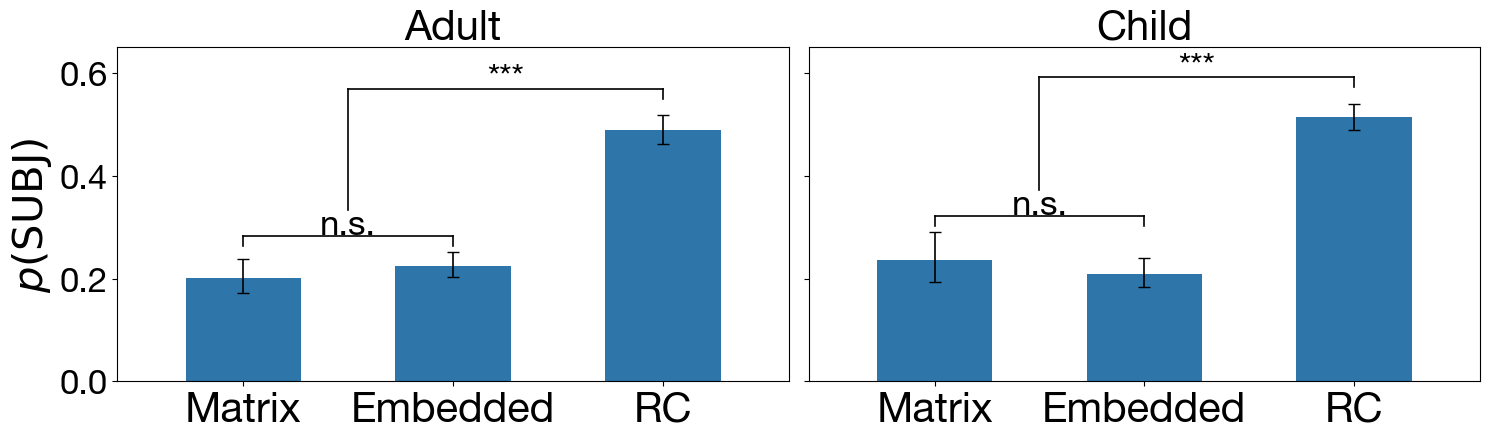

In [21]:
sA, sC = plot_p_subj_bars_adult_child_grouped_sig(sA, sC)

# Reproducing Figure 9 (Section 6) and Figure 12 (Appendix G)

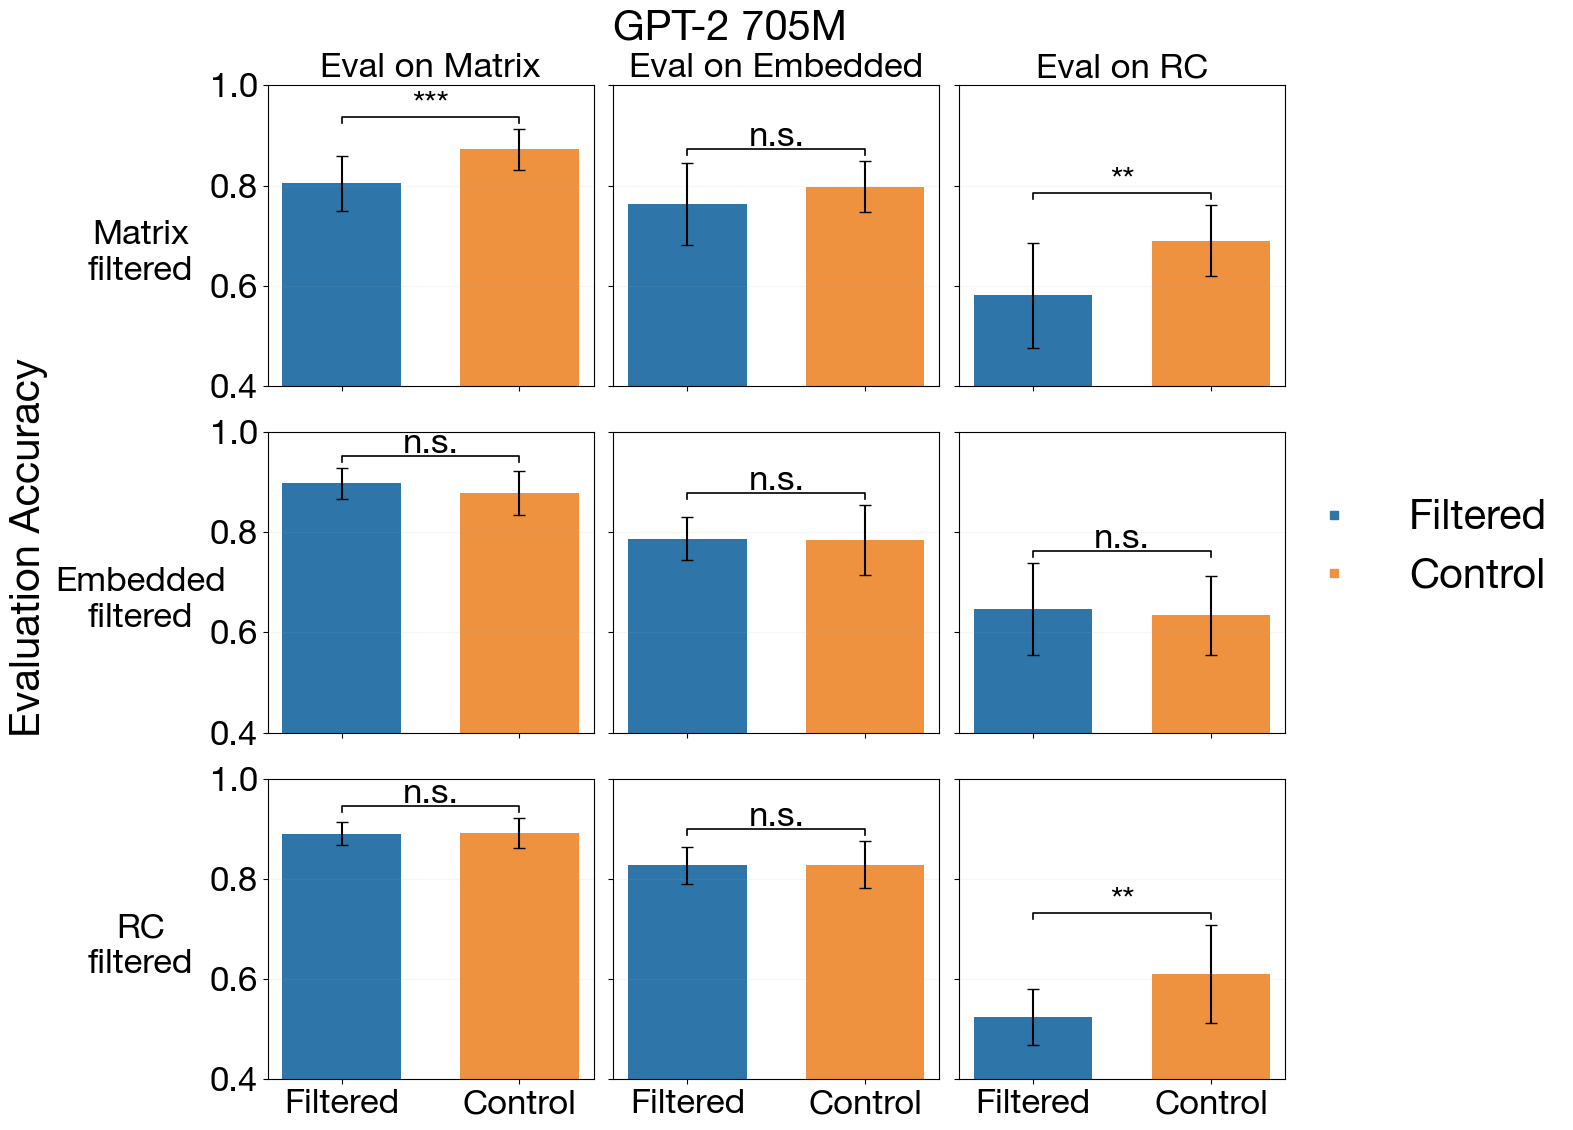

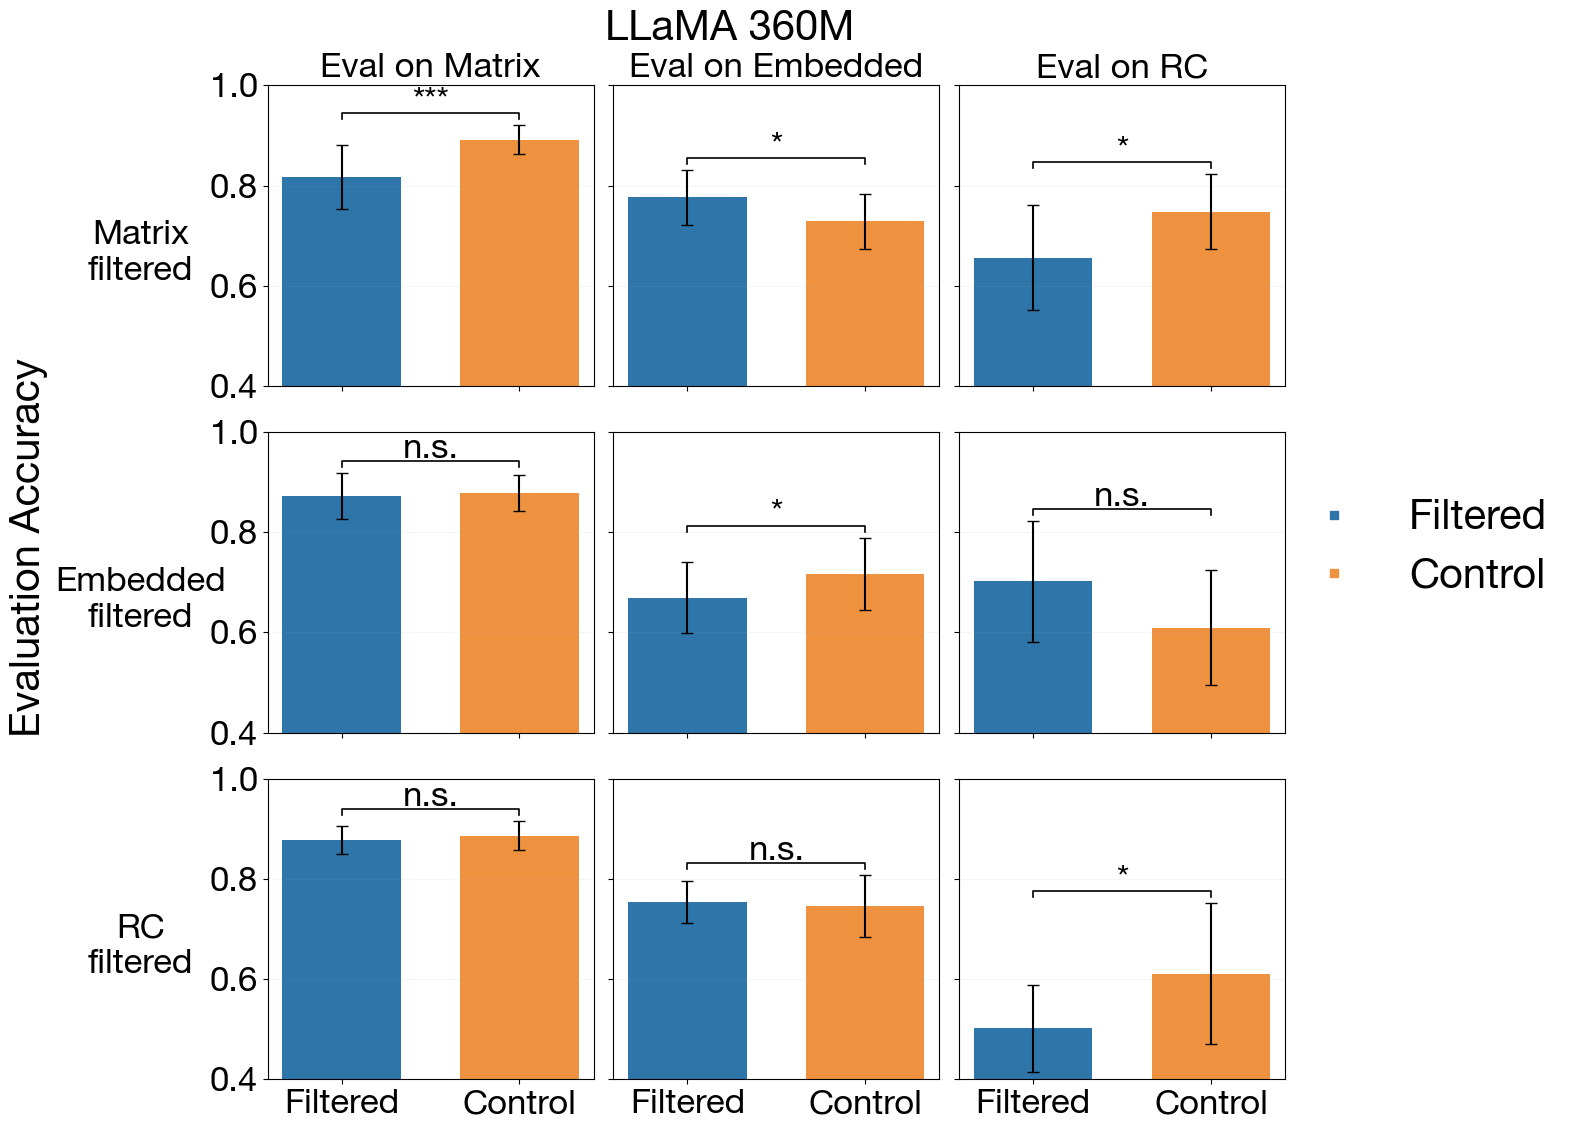

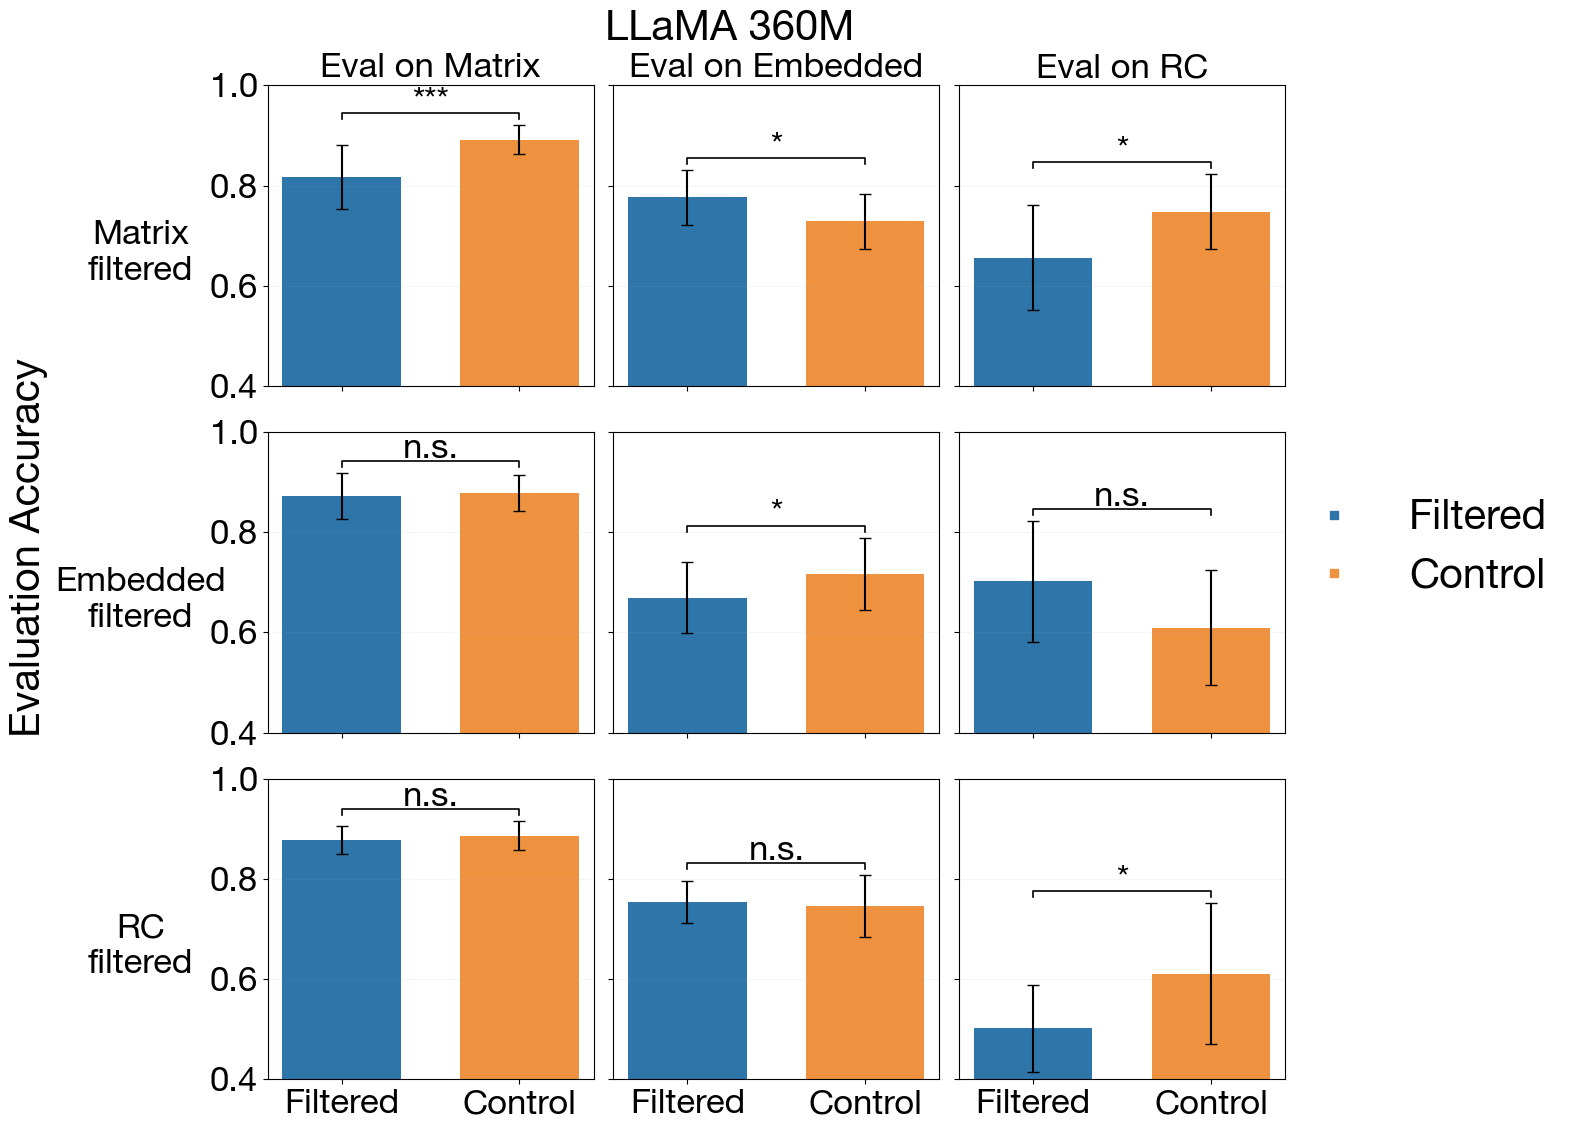

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Load
# ---------------------------
lm_df = pd.read_csv(f'{STATS_DIR}/babylm_statistics.csv')


# ---------------------------
# Ordering + pretty labels
# ---------------------------
ROW_ORDER = ["matrix_questions", "embedded_questions", "relative_clauses"]
COL_ORDER = ["matrix", "embedded", "relative"]

ROW_LABEL = {
    "matrix_questions": "Matrix",
    "embedded_questions": "Embedded",
    "relative_clauses": "RC",
}
COL_LABEL = {
    "matrix": "Matrix",
    "embedded": "Embedded",
    "relative": "RC",
}


# ---------------------------
# Significance helpers
# ---------------------------
def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."

def add_sig_bracket(ax, x1, x2, y, text, *, dy=0.01, lw=1.2, fs=10):
    """Draw a bracket between x1 and x2 at baseline y (data coords)."""
    if not text:
        return
    ax.plot([x1, x1, x2, x2], [y, y+dy, y+dy, y], lw=lw, color="black", clip_on=False)
    ax.text((x1+x2)/2, y+dy/3, text, ha="center", va="bottom", fontsize=fs)


# ---------------------------
# Main plotting function
# ---------------------------
def plot_3x3_ablation_vs_control(
    df: pd.DataFrame,
    model_config: str,
    *,
    row_order=ROW_ORDER,
    col_order=COL_ORDER,
    row_label=ROW_LABEL,
    col_label=COL_LABEL,
    figsize=(15, 12.5),
    bar_width=0.4,
    # appearance knobs
    color_ablated="#2e75a9",
    color_control="#ef9240",
    ylim=(0.4, 1.0),
    y_label="Evaluation Accuracy",
    title_fontsize=30,
    panel_title_fontsize=25,
    tick_fontsize=25,
    label_fontsize=30,
    star_fontsize=25,
    # bracket placement knobs (relative to data range)
    bracket_pad_frac=0.02,   # pad above tallest bar+err in panel
    bracket_dy_frac=0.02,    # bracket height
):
    sub = df[df["model_config"] == model_config].copy()

    fig, axes = plt.subplots(
        nrows=len(row_order),
        ncols=len(col_order),
        figsize=figsize,
        sharey=True,
        sharex=True,
    )

    # global title
    if model_config == 'gpt-705M':
        display_name = "GPT-2 705M"
    elif model_config == 'llama-360M':
        display_name = "LLaMA 360M"
    else:
        display_name = model_config
    fig.suptitle(f"{display_name}", fontsize=title_fontsize, y=0.93)

    yr = ylim[1] - ylim[0]
    bracket_dy = bracket_dy_frac * yr

    for i, r in enumerate(row_order):
        for j, c in enumerate(col_order):
            ax = axes[i, j]

            cell = sub[(sub["dataset_filter"] == r) & (sub["minimal_pair_category"] == c)]
            if cell.empty:
                # Keep an empty panel but label axes
                ax.set_ylim(*ylim)
                ax.set_xticks([0, 1])
                ax.set_xticklabels(["Filtered", "Control"], fontsize=tick_fontsize)
                ax.grid(axis="y", alpha=0.2)
                continue

            row = cell.iloc[0]

            # bars
            means = [row["ablated_mean"], row["control_mean"]]
            stds  = [row["ablated_std"],  row["control_std"]]

            pair_gap = 0.6
            x = np.array([0, pair_gap])
            ax.bar(x[0], means[0], yerr=stds[0], width=bar_width,
                   color=color_ablated, capsize=4, edgecolor="none", label="Filtered")
            ax.bar(x[1], means[1], yerr=stds[1], width=bar_width,
                   color=color_control, capsize=4, edgecolor="none", label="Control")

            ax.set_ylim(*ylim)
            ax.grid(axis="y", alpha=0.1)

            # x tick labels only on bottom row
            ax.set_xticks(x)
            if i == len(row_order) - 1:
                ax.set_xticklabels(["Filtered", "Control"], fontsize=tick_fontsize, rotation=0)
            else:
                ax.set_xticklabels(["", ""], fontsize=tick_fontsize)

            ax.tick_params(axis="y", labelsize=tick_fontsize)

            # panel title only on top row
            if i == 0:
                ax.set_title(f"Eval on {col_label.get(c, c)}", fontsize=panel_title_fontsize)

            # row labels on leftmost column
            if j == 0:
                ax.set_ylabel(f"\n{row_label.get(r, r)}\nfiltered", fontsize=panel_title_fontsize, rotation=0, labelpad=50, va="center")

            # significance bracket (Ablated vs Control)
            stars = p_to_stars(row["p_value"])
            top = max(means[0] + stds[0], means[1] + stds[1])
            y_bracket = min(ylim[1] - 3*bracket_dy, top + bracket_pad_frac * yr)
            add_sig_bracket(ax, x[0], x[1], y_bracket, stars, dy=bracket_dy, fs=star_fontsize)

    # one shared y label (optional)
    fig.text(0.02, 0.5, y_label, rotation=90, va="center", fontsize=label_fontsize)

    # legend once (outside)
    handles = [
        plt.Line2D([0],[0], marker="s", linestyle="", color=color_ablated, label="Filtered"),
        plt.Line2D([0],[0], marker="s", linestyle="", color=color_control, label="Control"),
    ]
    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.85, 0.5), frameon=False, fontsize=label_fontsize)

    fig.tight_layout(rect=[0.04, 0.03, 0.88, 0.95])
    plt.show()
    fig.savefig(f"{STATS_DIR}/figures/{model_config}_ablation_vs_control.pdf", dpi=300, bbox_inches="tight")
    return fig


# ---------------------------
# Produce the two figures
# ---------------------------
plot_3x3_ablation_vs_control(lm_df, "gpt-705M")
plot_3x3_ablation_vs_control(lm_df, "llama-360M")
